# Concatenating, Joining, and Pivoting Data

There are several ways of answering many questions in this notebook, but try to use the new operations (concatenate, joint/merge, pivot) whenever possible to get practice.

In [2]:
import pandas as pd

## Movie Ratings Data

The Movielens data set (https://dlsun.github.io/pods/data/ml-1m/ ) contains 1 million movie ratings submitted by users. The information about the movies, ratings, and users are stored in three separate files, called `movies.dat`, `ratings.dat`, and `users.dat`. The column names are not included with the data files. Refer to the webpage above for more information.


1\. Read in each of the data files.


(Hint: see the note in the documentation about the delimiter; use the `sep` argument in `read_csv`. If you get an error when reading the `movies.dat` file, try `encoding_errors = "ignore"` in `read_csv`.)

In [3]:
# YOUR CODE HERE
base = "https://dlsun.github.io/pods/data/ml-1m/"

movies_url = base + "movies.dat"
rating_url = base + "ratings.dat"
users_url = base + "users.dat"
movies_df = pd.read_csv(movies_url,sep = "::",
                        encoding_errors="ignore",
                        header = None,
                        names = ["movies_id", "title", "genre"])
rating_df = pd.read_csv(rating_url,sep = "::",
                        encoding_errors="ignore",
                        header = None,
                        names = ["user_id", "movie_id", "rating", "timestamp"])
user_df = pd.read_csv(users_url,sep = "::",
                        encoding_errors="ignore",
                        header = None,
                        names = ["user_id", "gender", "age", "occupation", "zip"])

<positron-console-cell-3>:7: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
<positron-console-cell-3>:11: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
<positron-console-cell-3>:15: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


In [4]:
rating_df.head()

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [5]:
movies_df.head()

,movies_id,title,genre
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [6]:
user_df.head()

,user_id,gender,age,occupation,zip
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


2\. Which age group tends to give the highest ratings? Create an appropriate summary to answer this question.

(Note the way age is coded in the [REAMDE file](https://dlsun.github.io/pods/data/ml-1m/README.txt).)

In [7]:

# YOUR CODE HERE
rating_user_df = rating_df.merge(user_df, on="user_id", how='left', validate="many_to_one")

age_label = {1:"<18", 18:"18-24", 25:"25-34", 35:"35-44", 45:"45-49", 50:"50-55", 56:"56+"}
rating_user_df["age_group"] = rating_user_df["age"].map(age_label)


In [8]:
(rating_user_df.groupby("age_group")["rating"].agg(n_rating = "size", mean_rating = "mean").sort_values("mean_rating", ascending=False).reset_index())

,age_group,n_rating,mean_rating
0,56+,38780,3.766632
1,50-55,72490,3.714512
2,45-49,83633,3.638062
3,35-44,199003,3.618162
4,<18,27211,3.549520
5,25-34,395556,3.545235
6,18-24,183536,3.507573


3\. Among movies with at least 100 ratings, which movies had the highest average rating? The lowest?

In [12]:

sum_ratings_df = (rating_df.groupby("movie_id")["rating"].agg(n_rating="size",mean_rating="mean")
.reset_index())

movies_rating_df = sum_ratings_df.merge(movies_df, left_on="movie_id", right_on="movies_id", how="left")


movies_100 = movies_rating_df[movies_rating_df["n_rating"] >= 100]

movies_100.sort_values("mean_rating", ascending=False).head(10)



,movie_id,n_rating,mean_rating,movies_id,title,genre
1839,2019,628,4.560510,2019,Seven Samurai (The Magnificent Seven) (Shichin...,Action|Drama
309,318,2227,4.554558,318,"Shawshank Redemption, The (1994)",Drama
802,858,2223,4.524966,858,"Godfather, The (1972)",Action|Crime|Drama
708,745,657,4.520548,745,"Close Shave, A (1995)",Animation|Comedy|Thriller
49,50,1783,4.517106,50,"Usual Suspects, The (1995)",Crime|Thriller
513,527,2304,4.510417,527,Schindler's List (1993),Drama|War
1066,1148,882,4.507937,1148,"Wrong Trousers, The (1993)",Animation|Comedy
861,922,470,4.491489,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Film-Noir
1108,1198,2514,4.477725,1198,Raiders of the Lost Ark (1981),Action|Adventure
843,904,1050,4.476190,904,Rear Window (1954),Mystery|Thriller


4\. For each movie, calculate the average rating and the proportion of the ratings that were from users aged 18-24. Make a scatterplot showing the relationship between the average rating and the 18-24 share, with each point representing a movie. (Optional: Use the size of each point to represent the number of users who rated the movie.)

In [13]:
# YOUR CODE HERE
rating_user_df["is_18_24"] = (rating_user_df["age_group"] == "18-24").astype(int)

movie_age_summary = (rating_user_df.groupby("movie_id").agg(mean_rating=("rating", "mean"),
prop_18_24=("is_18_24", "mean"), n_ratings=("rating", "size"))
.reset_index())

movie_age_summary.head()

,movie_id,mean_rating,prop_18_24,n_ratings
0,1,4.146846,0.215696,2077
1,2,3.201141,0.219686,701
2,3,3.016736,0.223849,478
3,4,2.729412,0.229412,170
4,5,3.006757,0.219595,296


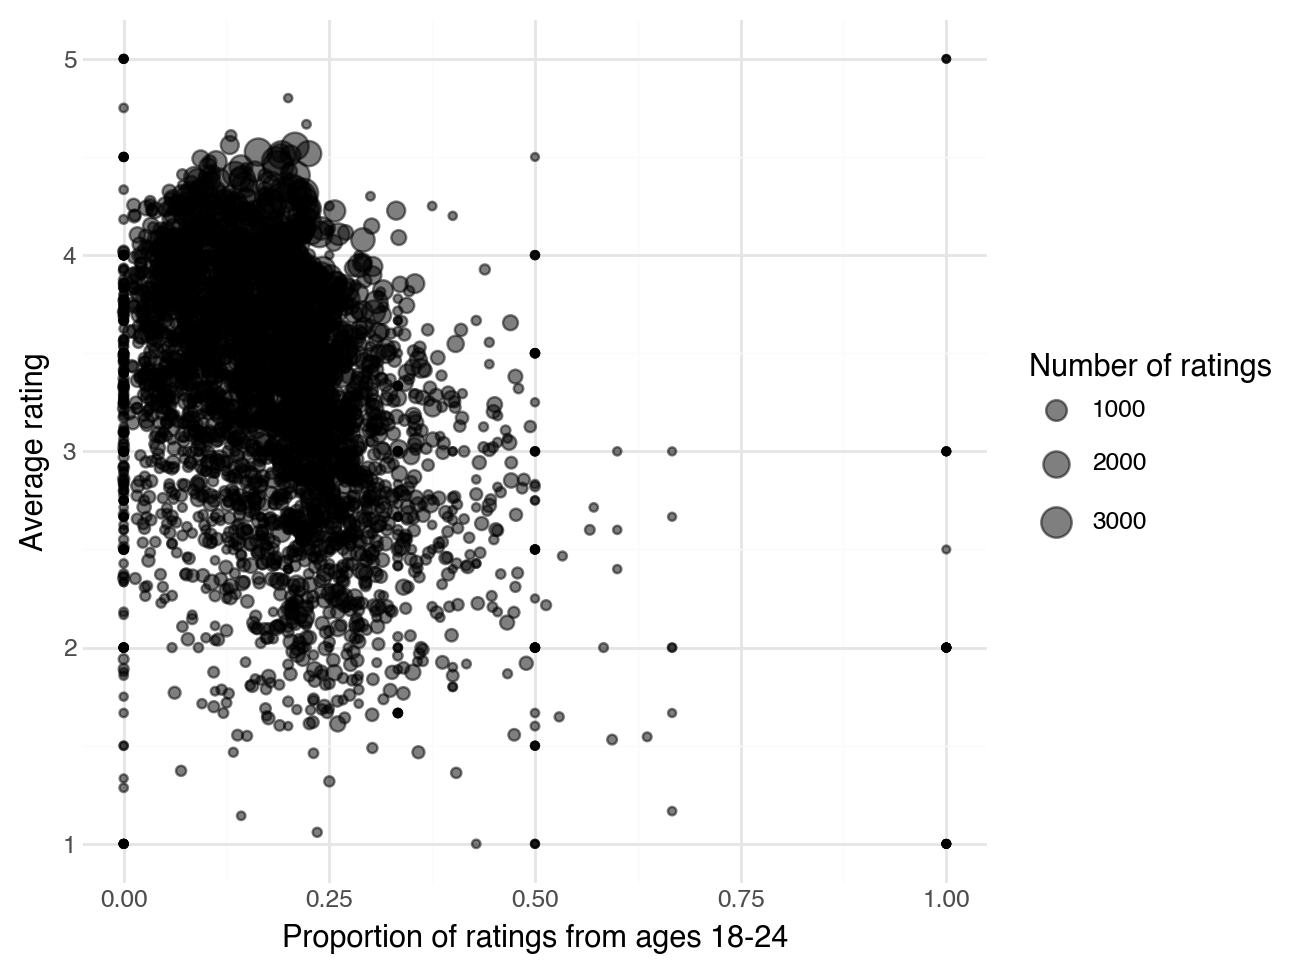

In [14]:
from plotnine import *

(ggplot( movie_age_summary,aes(x="prop_18_24", y="mean_rating", size="n_ratings"))
+ geom_point(alpha=0.5)
+ labs( x="Proportion of ratings from ages 18-24", y="Average rating", size="Number of ratings")
+ theme_minimal())

5\. Calculate the number of ratings by movie. How many of the movies had zero ratings?

(_Hint_: Why is an inner join not sufficient here?)

In [15]:
# YOUR CODE HERE
rating_counts = (rating_df.groupby("movie_id").size()
.reset_index(name="n_ratings"))

movie_counts = movies_df.merge(rating_counts, left_on="movies_id", right_on="movie_id", how="left"
)

movie_counts["n_ratings"] = movie_counts["n_ratings"].fillna(0)

movie_counts.head()

,movies_id,title,genre,movie_id,n_ratings
0,1,Toy Story (1995),Animation|Children's|Comedy,1.0,2077.0
1,2,Jumanji (1995),Adventure|Children's|Fantasy,2.0,701.0
2,3,Grumpier Old Men (1995),Comedy|Romance,3.0,478.0
3,4,Waiting to Exhale (1995),Comedy|Drama,4.0,170.0
4,5,Father of the Bride Part II (1995),Comedy,5.0,296.0


In [16]:
(movie_counts["n_ratings"] == 0).sum()

np.int64(177)

6\. How many movies received both a 1 and a 5 rating? Which movies? How many ratings of each type (1 or 5 stars)? Answer these question by joining two appropriate tables.

In [17]:
# YOUR CODE HERE

one_star = (rating_df[rating_df["rating"] == 1].groupby("movie_id")
.size().reset_index(name="one_star_ratings"))

five_star = (rating_df[rating_df["rating"] == 5].groupby("movie_id")
.size().reset_index(name="five_star_ratings"))

both_ratings = one_star.merge(five_star, on="movie_id", how="inner")

both_ratings = both_ratings.merge(movies_df, left_on="movie_id", right_on="movies_id", how="left")

both_ratings[["title", "one_star_ratings", "five_star_ratings"]]

,title,one_star_ratings,five_star_ratings
0,Toy Story (1995),16,820
1,Jumanji (1995),42,48
2,Grumpier Old Men (1995),44,43
3,Waiting to Exhale (1995),21,6
4,Father of the Bride Part II (1995),28,16
...,...,...,...
2981,Meet the Parents (2000),35,163
2982,Requiem for a Dream (2000),9,132
2983,Tigerland (2000),2,12
2984,Two Family House (2000),1,14


In [18]:
len(both_ratings)

2986